# Q5 PCA

In [ ]:
!pip install tensorflow

In [2]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import numpy as np
import pandas as pd

## 5.1 Custom Implementation of PCA

In [3]:
class PCA:
    """
      Principal Component Analysis (PCA) implementation.
    """
    def __init__(self, n_components):
        """ Initialize PCA with the number of components to keep. """
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        """ Fit the PCA model to the data X. """
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)

    def transform(self, X):
        """ Apply the dimensionality reduction on X. """
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def inverse_transform(self, X_reduced):
        """ Transform the reduced data back to the original space. """
        return np.dot(X_reduced, self.components.T) + self.mean

    def checkPCA(self, X):
        """ Check if the PCA transformation is correct. """
        X_reduced = self.transform(X)
        return X_reduced.shape[1] == self.n_components

In [4]:
digits = load_digits()
X = digits.data  # shape (1797, 64)

pca = PCA(n_components=2)
pca.fit(X)
X_reduced = pca.transform(X)
print("Reduced shape:", X_reduced.shape)
print("Check PCA:", pca.checkPCA(X))

Reduced shape: (1797, 2)
Check PCA: True


## 5.2 PCA on MNIST

In [5]:
(X_train, y_train), (_, _) = mnist.load_data()

X_subset = []
y_subset = []
for digit in range(10):
    idx = np.where(y_train == digit)[0][:100]  # first 100 indices for that digit
    X_subset.append(X_train[idx])
    y_subset.append(y_train[idx])

X_subset = np.concatenate(X_subset, axis=0)
y_subset = np.concatenate(y_subset, axis=0)

In [12]:
X_flat = X_subset.reshape((1000, -1))
X_flat.shape

(1000, 784)

In [7]:
dims = [500, 300, 150, 30]
pca_models = {}
X_reduced = {}
X_reconstructed = {}

for d in dims:
    pca = PCA(n_components=d)
    pca.fit(X_flat)
    X_red = pca.transform(X_flat)
    X_recon = pca.inverse_transform(X_red)
    pca_models[d] = pca
    X_reduced[d] = X_red
    X_reconstructed[d] = X_recon

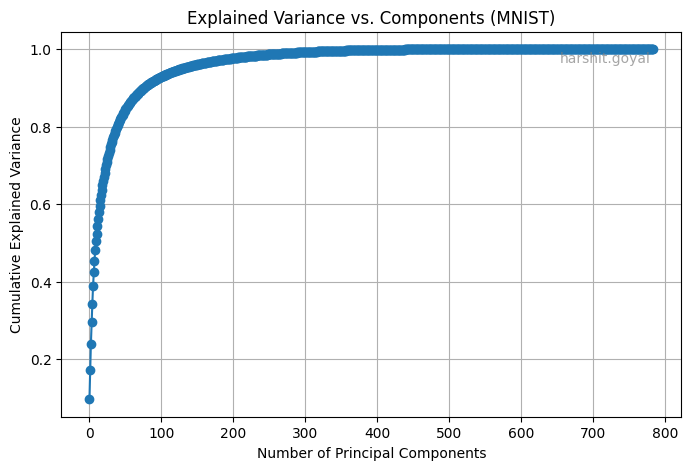

In [8]:
plt.figure(figsize=(8,5))
pca_full = PCA(n_components=784)
pca_full.fit(X_flat)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Components (MNIST)")
plt.grid(True)
plt.text(0.95, 0.95, "harshit.goyal", ha='right', va='top', transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.show()

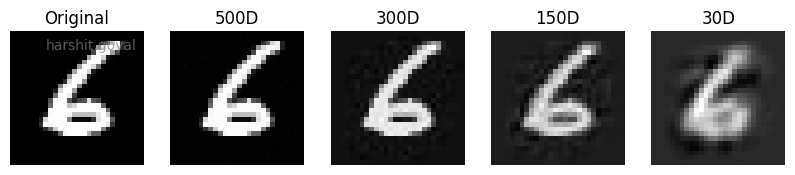

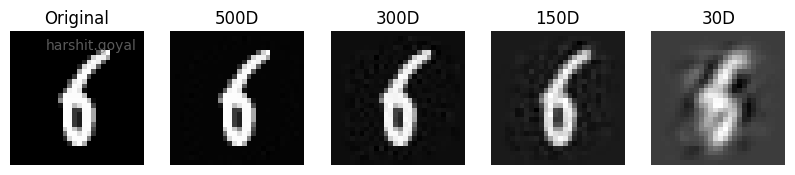

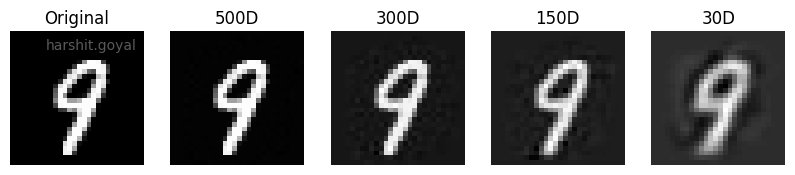

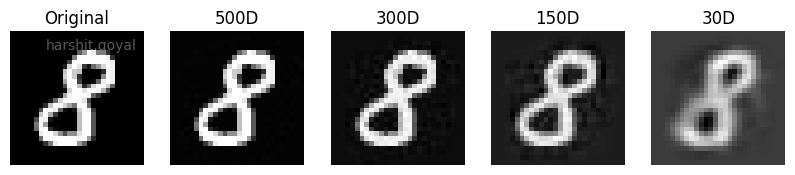

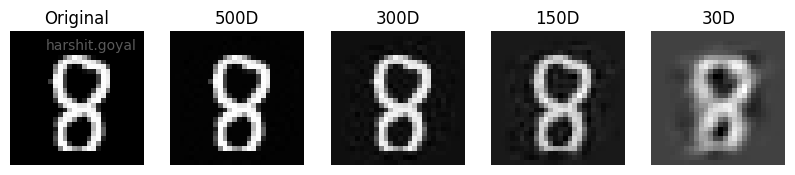

In [9]:
sample_idx = np.random.choice(1000, 5, replace=False)

for idx in sample_idx:
    plt.figure(figsize=(10, 3))
    # Original
    plt.subplot(1, len(dims)+1, 1)
    plt.imshow(X_flat[idx].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")
    plt.text(0.95, 0.95, "harshit.goyal", ha='right', va='top', transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)

    # Reconstructions
    for j, d in enumerate(dims):
        plt.subplot(1, len(dims)+1, j+2)
        plt.imshow(X_reconstructed[d][idx].reshape(28,28), cmap='gray')
        plt.title(f"{d}D")
        plt.axis("off")
    
    plt.show()

#### Variance Plot Explanation:
- The explained variance rises quickly with the first few hundred components.
- After ~150 components, the curve starts flattening (elbow point), meaning extra components add little new information.
- Around 500 components, almost all the variance of the dataset (>95%) is captured.
#### Trade off
- As the number of components decreases, reconstruction quality drops, but storage/computation cost also reduces.
- For classification tasks, ~150 components may be a good trade-off: high variance retention, much smaller dimension than 784.
- For visualization or extreme compression, 30 components are enough, but accuracy would suffer if used for downstream tasks.